In [1]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

$$
G(s)=\frac{1}{s(s+B)}=\frac{1}{s^2+0.5s}
$$

In [2]:
def Gs(B):
    return ctrl.TransferFunction([1], [1, B, 0])

# Parte A - Analisis de Sensibilidad y Robustez

### a.

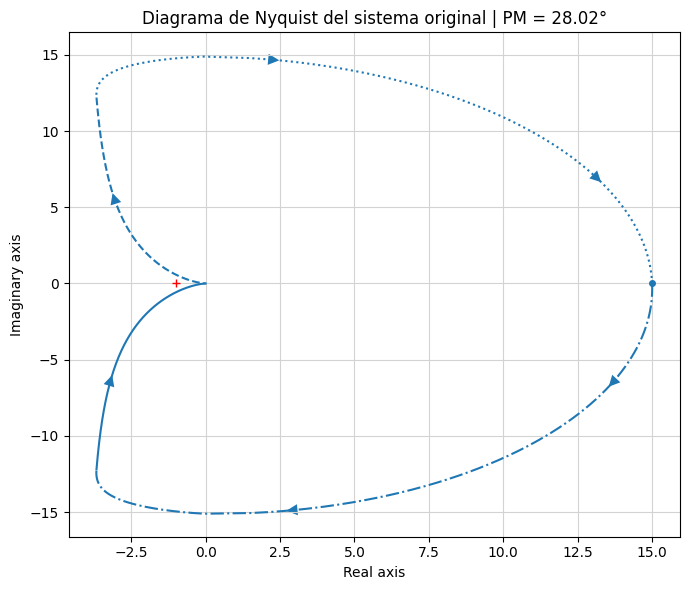

In [3]:
G = Gs(0.5)
gm, pm, wg, wp = ctrl.margin(G)

# Diagrama de Nyquist
fig, ax = plt.subplots(figsize=(7, 6))
ctrl.nyquist_plot(G, ax=ax)
ax.set_title(f'Diagrama de Nyquist del sistema original | PM = {pm:.2f}°')
ax.grid(True)
plt.tight_layout()
fig.savefig('Latex/figures/ej2_nyquist_nominal.png', dpi=150, bbox_inches='tight')
plt.show()

$$
Z = N + P
$$

Donde:

$$
N = 0
\quad\text{(ninguna vuelta alrededor de }(-1,0)\text{)}
$$

$$
P = 0
\quad\text{(}G(s)\text{ no tiene polos en el semiplano derecho estricto}
$$

Por lo tanto:

$$
Z = 0 + 0 = 0
$$

Conclusión: el sistema en lazo cerrado es estable con B = 0.5.

### b.

/home/juan/miniconda3/envs/dev/lib/python3.11/site-packages/control/timeresp.py:1088: UserWarning: Non-zero initial condition given for transfer function system. Internal conversion to state space used; may not be consistent with given X0.
  warnings.warn(


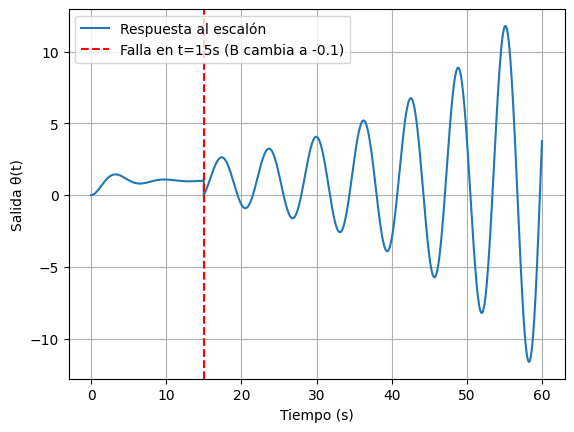

In [4]:
# Tramo 1
G1 = Gs(0.5)
T1 = ctrl.feedback(G1, 1)

t1 = np.linspace(0, 15, 1000)
t1, y1 = ctrl.step_response(T1, t1)

# Tramo 2
G2 = Gs(-0.1)
T2 = ctrl.feedback(G2, 1)

t2 = np.linspace(15, 60, 1000)
X0 = np.array([y1[-1], 0])  # Condición inicial para el tramo 2
t2, y2 = ctrl.forced_response(T2, T=t2, U=np.ones_like(t2), X0=X0)

t = np.concatenate((t1, t2))
y = np.concatenate((y1, y2))

plt.figure()
plt.plot(t, y, label='Respuesta al escalón')
plt.axvline(x=15, color='r', linestyle='--', label='Falla en t=15s (B cambia a -0.1)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida θ(t)')
plt.legend()
plt.grid()
plt.savefig('Latex/figures/ej2_fault_response.png', dpi=150, bbox_inches='tight')
plt.show()

SUPER INESTABLE NOOOO

### c.

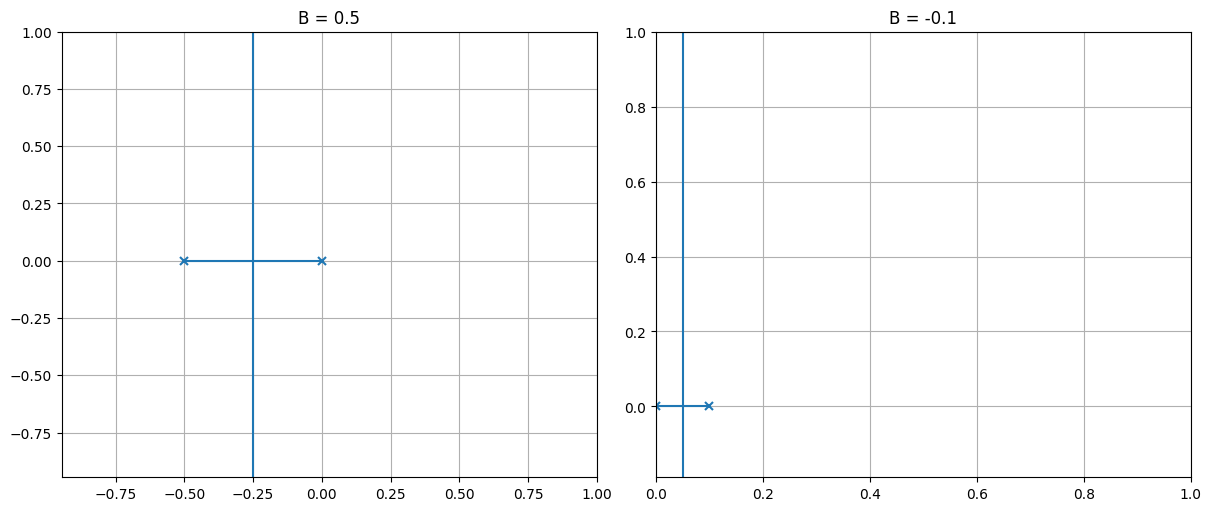

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

ctrl.root_locus_plot(G1, ax=axes[0])
axes[0].set_title('B = 0.5')
axes[0].grid(True)

ctrl.root_locus_plot(G2, ax=axes[1])
axes[1].set_title('B = -0.1')
axes[1].grid(True)

fig.savefig('Latex/figures/ej2_root_locus.png', dpi=150, bbox_inches='tight')
plt.show()

### d.

G1 = B = 0.5
  Margen de ganancia: inf
  Margen de fase: 28.02017611933482

G2 = B = -0.1
  Margen de ganancia: inf
  Margen de fase: -5.724792592138272



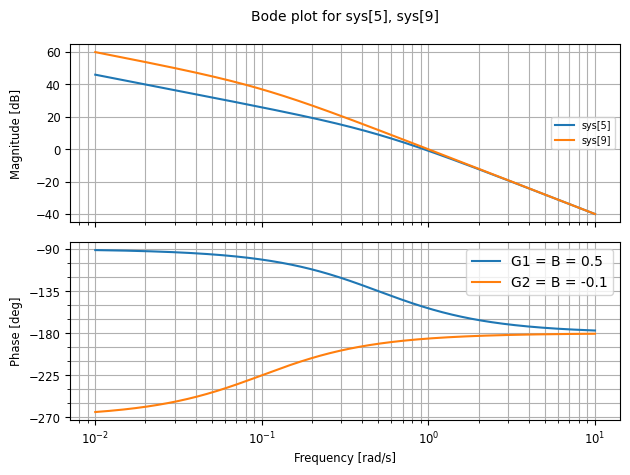

In [6]:
gm1, pm1, wg1, wp1 = ctrl.margin(G1)
gm2, pm2, wg2, wp2 = ctrl.margin(G2)

print("G1 = B = 0.5")
print(f"  Margen de ganancia: {gm1}")
print(f"  Margen de fase: {pm1}")
print()

print("G2 = B = -0.1")
print(f"  Margen de ganancia: {gm2}")
print(f"  Margen de fase: {pm2}")
print()

plt.figure()
ctrl.bode_plot([G1, G2], dB=True)
plt.legend(["G1 = B = 0.5", "G2 = B = -0.1"])
plt.savefig('Latex/figures/ej2_bode_fault.png', dpi=150, bbox_inches='tight')
plt.show()

Margen de Fase es negativo cuando B = -0.1 entonces deberiamos usar un compensador lead para que aporte fase positiva para aumentar el margen de fase del sistema. 

# Parte B - Diseño de Compensador para Estabilidad Robusta

### a. Compensador Lead:

$$
C(s)=K_c\,\frac{s+\frac{1}{T}}{s+\frac{1}{\alpha T}}, 
\qquad 0<\alpha<1
$$

Definiendo
$$
z=\frac{1}{T}, 
\qquad 
p=\frac{1}{\alpha T},
$$
se obtiene
$$
z=\alpha\,p.
$$

Si se normaliza la ganancia estática del compensador:
$$
C(0)=K_c\,\frac{\frac{1}{T}}{\frac{1}{\alpha T}}
=K_c\,\alpha=1
\;\Longrightarrow\;
K_c=\frac{1}{\alpha}.
$$

Para seleccionar $\alpha$, se usa la relación con el máximo adelanto de fase:
$$
\alpha=\frac{1-\sin\phi_{\max}}{1+\sin\phi_{\max}},
\qquad 0<\alpha<1.
$$

donde $\phi_{\max}$ es el aporte máximo de fase del compensador.

In [7]:
G = Gs(0.5)
gm, pm, wg, wp = ctrl.margin(G)

target_margins = [35, 50, 65]
print('Margen de fase:', pm)

for target in target_margins:
    print(f'Para un margen de fase objetivo de {target} grados, se necesita un aportador de fase de {target - pm:.2f} grados.')

Margen de fase: 28.02017611933482
Para un margen de fase objetivo de 35 grados, se necesita un aportador de fase de 6.98 grados.
Para un margen de fase objetivo de 50 grados, se necesita un aportador de fase de 21.98 grados.
Para un margen de fase objetivo de 65 grados, se necesita un aportador de fase de 36.98 grados.


Por lo tanto, se busca que el máximo adelanto de fase del compensador sea:

$$
\phi_{\max}=37^\circ
$$

Para compensar posibles pérdidas de fase debidas al desplazamiento de la frecuencia de cruce, se incorpora un margen de seguridad de $10^\circ$:

$$
\phi_{\max,\text{diseño}}=\phi_{\max}+10^\circ=47^\circ.
$$

Con esta elección se procede al cálculo de $\alpha$ en el diseño lead.

In [8]:
phi_max = 47 # grados, para el target mas exigente
phi_max_rad = np.radians(phi_max)
alpha = (1 - np.sin(phi_max_rad)) / (1 + np.sin(phi_max_rad))
print(f'alpha = {alpha:.4f}')

alpha = 0.1552


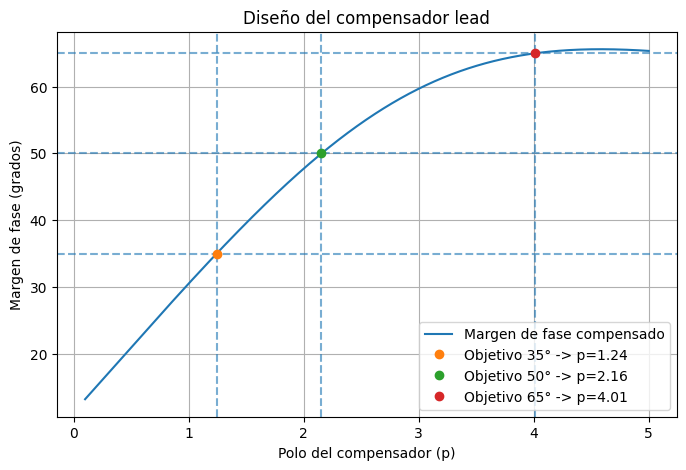

In [9]:
possible_poles = np.linspace(0.1, 5, 1000)
Kc = 1 / alpha

phase_margins = []
for p in possible_poles:
    z = alpha * p
    lead_tf = ctrl.TransferFunction([Kc, Kc * z], [1, p])
    pm = ctrl.margin(G * lead_tf)[1]
    phase_margins.append(pm if np.isfinite(pm) else np.nan)

phase_margins = np.array(phase_margins)

plt.figure(figsize=(8, 5))
plt.plot(possible_poles, phase_margins, label='Margen de fase compensado')
poles = []

for target_pm in target_margins:
    idx = np.nanargmin(np.abs(phase_margins - target_pm))
    p_opt = possible_poles[idx]
    pm_opt = phase_margins[idx]

    plt.axhline(target_pm, linestyle='--', alpha=0.6)
    plt.axvline(p_opt, linestyle='--', alpha=0.6)
    plt.plot(p_opt, pm_opt, 'o', label=f'Objetivo {target_pm}° -> p={p_opt:.2f}')
    poles.append(p_opt)

plt.xlabel('Polo del compensador (p)')
plt.ylabel('Margen de fase (grados)')
plt.title('Diseño del compensador lead')
plt.grid(True)
plt.legend()
plt.savefig('Latex/figures/ej2_lead_design.png', dpi=150, bbox_inches='tight')
plt.show()

### b. Bode de nuestro sistema con los distintos compensadores

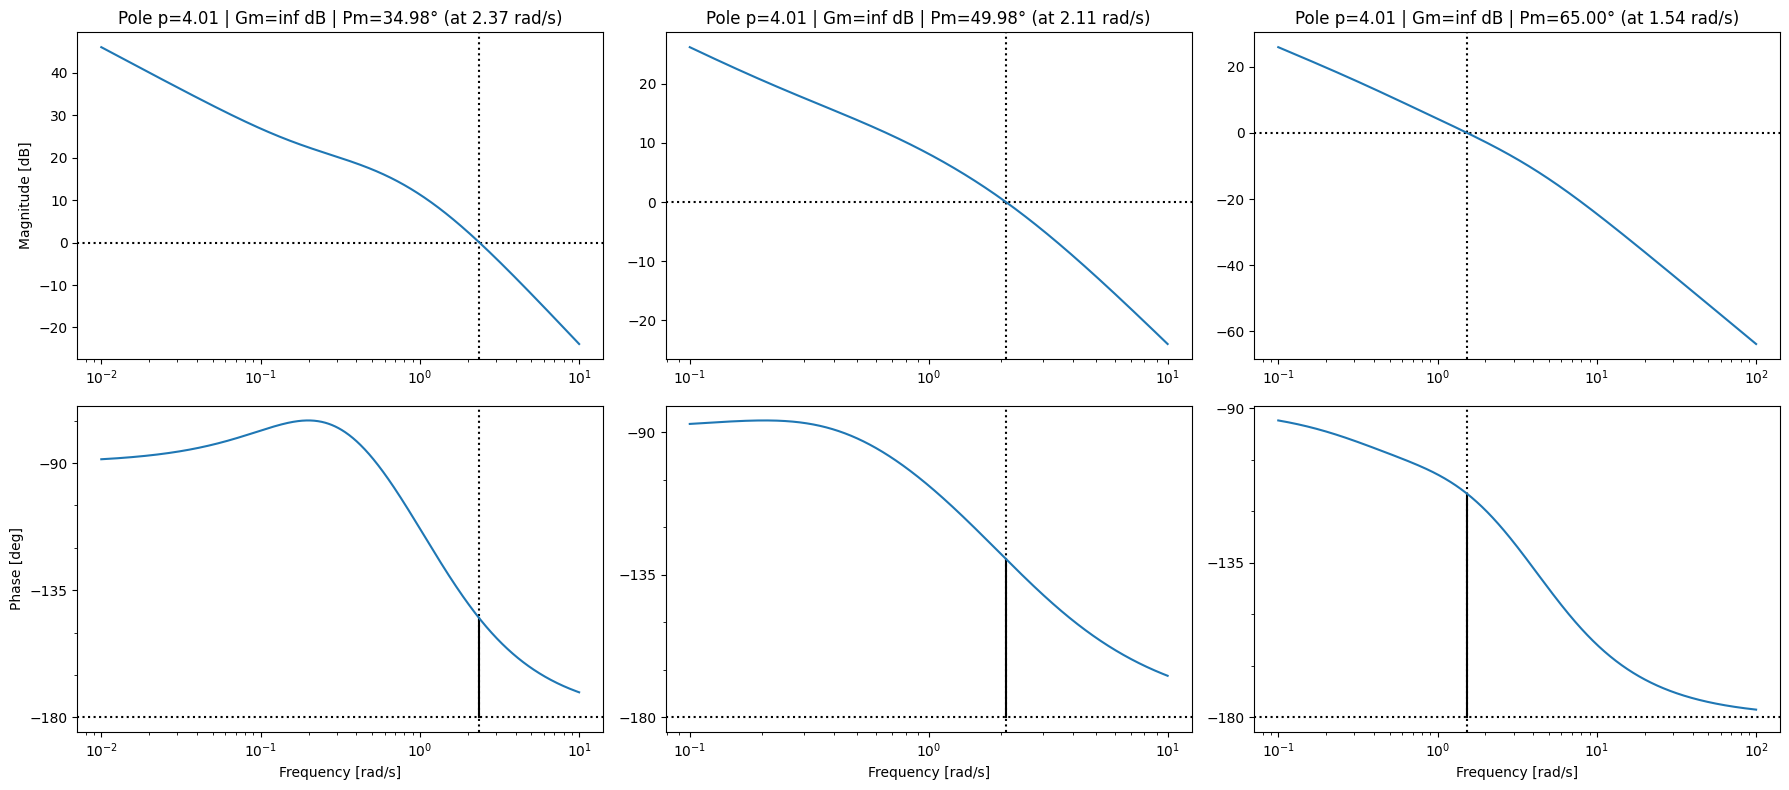

In [10]:
compensadores = []
for p in poles:
    z = alpha * p
    lead_tf = ctrl.TransferFunction([Kc, Kc * z], [1, p])
    compensadores.append(lead_tf)

fig, axes = plt.subplots(2, len(poles), figsize=(6 * len(poles), 8))

for i, lead_tf in enumerate(compensadores):
    sys_compensated = G * lead_tf
    
    # Bode plot del sistema compensado
    mag_ax = axes[0, i]
    phase_ax = axes[1, i]

    ctrl.bode_plot(sys_compensated, dB=True, display_margins=True, title=f'Bode plot con polo en p={p:.2f}', ax=(mag_ax, phase_ax))

    gm, pm, wg, wp = ctrl.margin(sys_compensated)
    mag_ax.set_title(f'Pole p={p:.2f} | Gm={gm:.2f} dB | Pm={pm:.2f}° (at {wp:.2f} rad/s)')

axes[0, 0].set_ylabel('Magnitude [dB]')
axes[1, 0].set_ylabel('Phase [deg]')

for i in range(1, len(poles)):
    axes[0, i].set_ylabel('')
    axes[1, i].set_ylabel('')

plt.tight_layout()
fig.savefig('Latex/figures/ej2_bode_compensated.png', dpi=150, bbox_inches='tight')
plt.show()

### c. Respuesta al escalon de los distintos compensadores

/home/juan/miniconda3/envs/dev/lib/python3.11/site-packages/control/timeresp.py:1082: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(
/home/juan/miniconda3/envs/dev/lib/python3.11/site-packages/control/timeresp.py:1088: UserWarning: Non-zero initial condition given for transfer function system. Internal conversion to state space used; may not be consistent with given X0.
  warnings.warn(


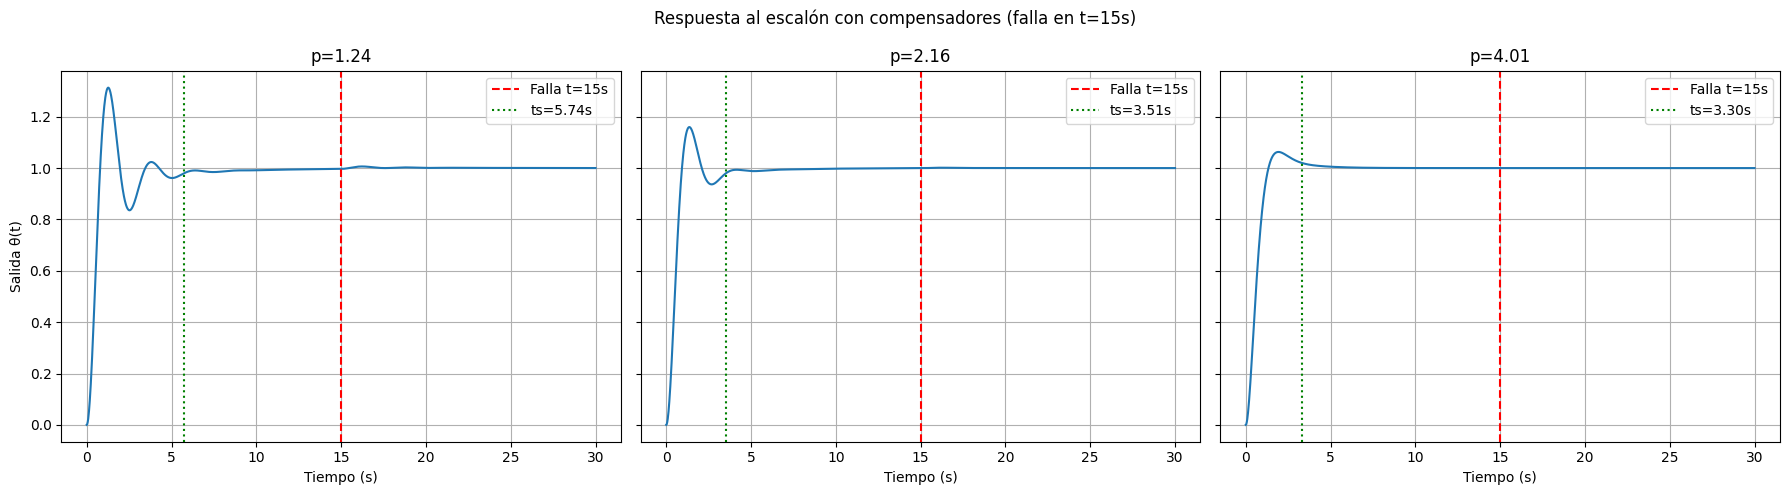

In [11]:
# Respuesta al escalón del sistema compensado con malfunction en t = 15s
fig, axes = plt.subplots(1, len(compensadores), figsize=(6 * len(compensadores), 5), sharey=True)

for i, (lead_tf, ax) in enumerate(zip(compensadores, axes)):
    # Tramo 1
    sys_compensated_1 = ctrl.feedback(G * lead_tf, 1)
    t1 = np.linspace(0, 15, 1000)
    t1, y1, x1 = ctrl.step_response(sys_compensated_1, t1, return_x=True)

    # Tramo 2
    sys_compensated_2 = ctrl.feedback(Gs(-0.1) * lead_tf, 1)
    t2 = np.linspace(15, 30, 1000)
    X0 = x1[:, -1]
    t2, y2, x2 = ctrl.forced_response(sys_compensated_2, T=t2, U=np.ones_like(t2), X0=X0, return_x=True)

    t = np.concatenate((t1, t2))
    y = np.concatenate((y1, y2))

    settled = np.where(np.abs(y - 1.0) > 0.02)[0]
    ts = t[settled[-1]] if len(settled) > 0 else 0

    ax.plot(t, y)
    ax.axvline(x=15, color='r', linestyle='--', label='Falla t=15s')
    ax.axvline(x=ts, color='g', linestyle=':', label=f'ts={ts:.2f}s')
    ax.set_xlabel('Tiempo (s)')
    ax.set_title(f'p={poles[i]:.2f}')
    ax.legend()
    ax.grid()

axes[0].set_ylabel('Salida θ(t)')
fig.suptitle('Respuesta al escalón con compensadores (falla en t=15s)')
plt.tight_layout()
fig.savefig('Latex/figures/ej2_step_fault_compensated.png', dpi=150, bbox_inches='tight')
plt.show()

Se pueden observar diversas características en estos gráficos. En primer lugar, en ningún caso la falla en $t = 15\,\text{s}$ provoca que el sistema se desestabilice y diverja como ocurría sin compensación. Esto refleja el efecto del compensador, que desplazó el polo inestable correspondiente a $B = -0.1$ hacia el semiplano izquierdo del plano complejo, garantizando la estabilidad del sistema. Como consecuencia, la falla es prácticamente imperceptible en la respuesta, a excepción del caso con menor compensación ($M_\phi = 35°$), donde se observa un pequeño error respecto a la referencia en el instante de la falla.

Con respecto al tiempo de establecimiento, los valores obtenidos para cada caso son:

| Compensador | Margen de Fase | $t_s$ |
|:-----------:|:--------------:|:-----:|
| $p = 1.24$  | $35°$          | $5.74\,\text{s}$ |
| $p = 2.16$  | $50°$          | $3.51\,\text{s}$ |
| $p = 4.01$  | $65°$          | $3.30\,\text{s}$ |

Se observa una reducción del $t_s$ a medida que aumenta el margen de fase. Asimismo, las oscilaciones disminuyen considerablemente, el sobrepico se reduce y la respuesta se vuelve más suave y monótona. A medida que se incrementa el margen de fase, el sistema se asemeja cada vez más a un **sistema de primer orden**, con una respuesta sin rebotes y un transitorio significativamente más amortiguado.

### d. Diagrama de Nyquist para los distintos compensadores

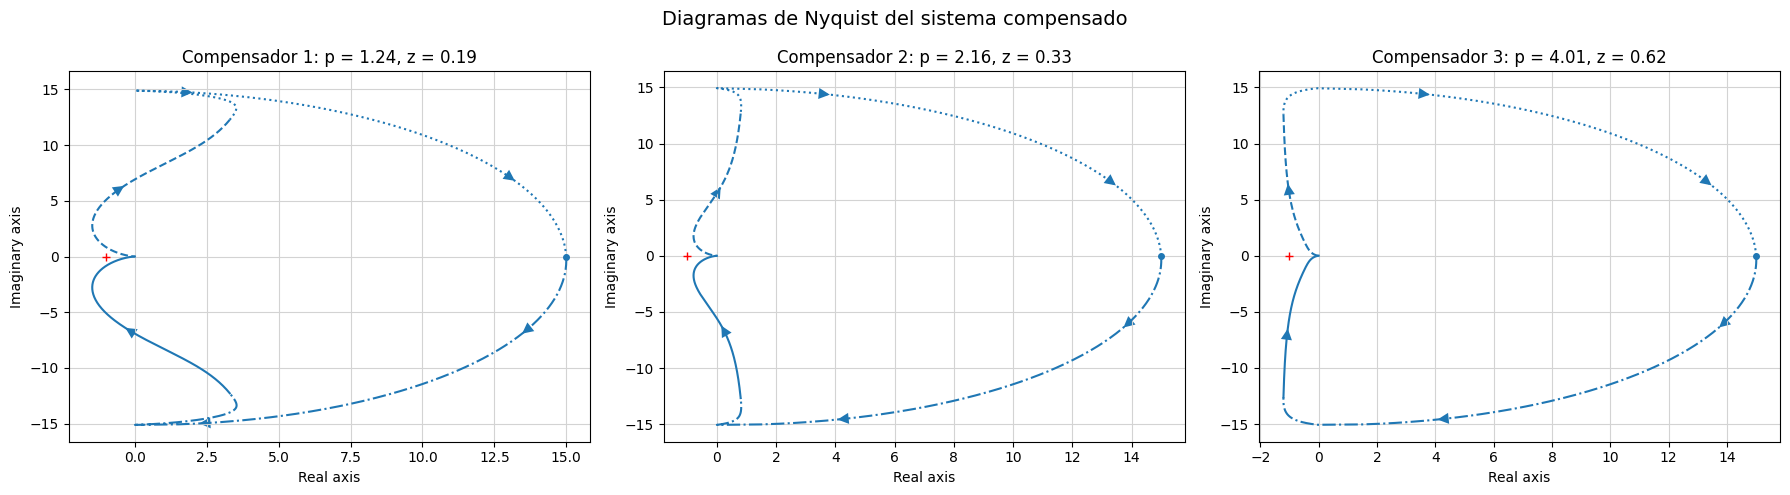

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (lead_tf, ax) in enumerate(zip(compensadores, axes)):
    G_compensated = G * lead_tf
    p = poles[i]
    z = alpha * p

    ctrl.nyquist_plot(G_compensated, ax=ax)
    ax.set_title(f'Compensador {i + 1}: p = {p:.2f}, z = {z:.2f}')
    ax.grid(True)

fig.suptitle('Diagramas de Nyquist del sistema compensado', fontsize=14)
plt.tight_layout()
fig.savefig('Latex/figures/ej2_nyquist_compensated.png', dpi=150, bbox_inches='tight')
plt.show()

En primer lugar, podemos comentar como en los 3 graficos la curva de Nyquist esta girando en sentido horario. Por lo tanto, si alguna perturbacion como la degradacion del motor, genera que la curva se acerque o rodee al punto critico, el sistema perderia estabilidad. Por lo tanto, el hecho de que al aumentar el margen de fase, la distancia minima de la curva al punto critico aumente demuestra la robustez del sistema compensado frente a degradaciones y perturbaciones. Al aumentar el margen de fase, el sistema aumenta su reserva de estabilidad para frontar estas situaciones. 

In [13]:
# ### e. Ancho de banda de los sistemas compensados

bandwidths = []
closed_loops = []

for i, lead_tf in enumerate(compensadores):
    T = ctrl.feedback(G * lead_tf, 1)   # lazo cerrado
    closed_loops.append(T)

    bw = T.bandwidth()   # rad/s
    bandwidths.append(bw)

    print(f'Compensador {i+1} | p={poles[i]:.2f} | PM objetivo={target_margins[i]}° | BW={bw:.4f} rad/s')


Compensador 1 | p=1.24 | PM objetivo=35° | BW=3.7153 rad/s
Compensador 2 | p=2.16 | PM objetivo=50° | BW=3.3696 rad/s
Compensador 3 | p=4.01 | PM objetivo=65° | BW=2.3627 rad/s
